In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset

import shap 
import json

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
import torch.nn.functional as torch_F # avoid import problems becasue F is used as a variable

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.mps.is_available(): device = torch.device("mps")
device

device(type='mps')

In [109]:
# From https://github.com/Rose-STL-Lab/CPTC/blob/main/algos/cptc.py
### This file contains two functions for running adaptive conformal inference in order to reproduce Figures 1, 2, 4, 5, 6, and 7 in https://arxiv.org/abs/2106.00170. 

from statsmodels.regression.quantile_regression import QuantReg
from scipy.optimize import minimize

class MultidimensionalQuantileRegression:
    def __init__(self, q=0.5, max_iter=1000):
        """
        Initialize the MultidimensionalQuantileRegression object.
        
        Parameters:
        q : float, optional (default=0.5)
            The quantile to estimate (0 < q < 1).
        max_iter : int, optional (default=1000)
            Maximum number of iterations for the optimization.
        """
        self.q = q
        self.max_iter = max_iter
        self.beta = None

    def fit(self, X, Y):
        """
        Fit the quantile regression model.
        
        Parameters:
        X : array-like of shape (n_samples, n_features)
            The input samples.
        Y : array-like of shape (n_samples, n_targets)
            The target values.
        
        Returns:
        self : object
            Returns self.
        """
        n_samples, n_features = X.shape
        n_targets = Y.shape[1]
        
        def objective(beta):
            beta = beta.reshape(n_features, n_targets)
            residuals = Y - X @ beta
            return np.sum(np.maximum(self.q * residuals, (self.q - 1) * residuals))
        
        beta_init = np.zeros(n_features * n_targets)
        
        result = minimize(objective, beta_init, method='BFGS', options={'maxiter': self.max_iter})
        
        self.beta = result.x.reshape(n_features, n_targets)
        
        return self

    def predict(self, X):
        """
        Predict using the fitted quantile regression model.
        
        Parameters:
        X : array-like of shape (n_samples, n_features)
            The input samples.
        
        Returns:
        Y_pred : array of shape (n_samples, n_targets)
            The predicted values.
        """
        if self.beta is None:
            raise ValueError("Model has not been fitted yet. Call 'fit' before using 'predict'.")
        
        return X @ self.beta

### Main method for forming election night predictions of county vote totals as in Figure 2

def ACI(Y, X, alpha, gamma, t_init=500, split_size=0.75, update_method="Simple", momentum_bw=0.95, max_band = 10):
    T = len(X)
    # Initialize data storage variables
    alpha_trajectory = [alpha] * (T - t_init)
    adapt_err_seq = [0] * (T - t_init)
    no_adapt_error_seq = [0] * (T - t_init)
    alpha_t = alpha
    band_native = []
    band_adapt = []
    
    for t in range(t_init, T):
        # Split data into training and calibration set
        train_points = np.random.choice(t, size=int(split_size*t), replace=False)
        cal_points = np.setdiff1d(np.arange(t), train_points)
        X_train, Y_train = X[train_points], Y[train_points]
        X_cal, Y_cal = X[cal_points], Y[cal_points]
        
        # flatten multi-dimensional inputs
        # X_train = X_train.reshape(X_train.shape[0], -1)
        # X_cal = X_cal.reshape(X_cal.shape[0], -1)
        # Y_train = Y_train.reshape(Y_train.shape[0], -1)
        # Y_cal = Y_cal.reshape(Y_cal.shape[0], -1)
        #print(X_train.shape, X_cal.shape, Y_train.shape, Y_cal.shape)

        # Fit quantile regression on training setting
        if len(X_train.shape) > 1:
            model_upper = MultidimensionalQuantileRegression(q=1-alpha/2)
            model_lower = MultidimensionalQuantileRegression(q=alpha/2)
            res_upper = model_upper.fit(X_train, Y_train)
            res_lower = model_lower.fit(X_train, Y_train)
        else:
            model_upper = QuantReg(Y_train, X_train)
            model_lower = QuantReg(Y_train, X_train)
            res_upper = model_upper.fit(q=1-alpha/2)
            res_lower = model_lower.fit(q=alpha/2)
        
        # Compute conformity score on calibration set and on new data example
        pred_low_for_cal = res_lower.predict(X_cal)
        pred_up_for_cal = res_upper.predict(X_cal)
        if len(X_train.shape) == 1:
            scores = np.maximum(Y_cal - pred_up_for_cal, pred_low_for_cal - Y_cal)
        else:
            scores = np.maximum( np.linalg.norm(Y_cal - pred_up_for_cal, axis=1), np.linalg.norm(pred_low_for_cal - Y_cal, axis=1))
        q_up = res_upper.predict(X[t].reshape(1, -1))[0]
        q_low = res_lower.predict(X[t].reshape(1, -1))[0]
        if len(X_train.shape) == 1:
            new_score = max(Y[t] - q_up, q_low - Y[t])
        else:
            new_score = np.maximum( np.linalg.norm(Y[t] - q_up), np.linalg.norm(q_low - Y[t]))
        
        # Compute errt for both methods
        conf_quant_naive = np.quantile(scores, 1-alpha)
        no_adapt_error_seq[t-t_init] = float(conf_quant_naive < new_score)
        band_native.append(conf_quant_naive)
        
        if alpha_t >= 1:
            adapt_err_seq[t-t_init] = 1
            band_adapt.append(0)
        elif alpha_t <= 0:
            adapt_err_seq[t-t_init] = 0
            band_adapt.append(max_band)
        else:
            conf_quant_adapt = np.quantile(scores, 1-alpha_t)
            adapt_err_seq[t-t_init] = float(conf_quant_adapt < new_score)
            band_adapt.append(conf_quant_adapt)
        # update alpha_t
        alpha_trajectory[t-t_init] = alpha_t
        if update_method == "Simple":
            alpha_t += gamma * (alpha - adapt_err_seq[t-t_init])
        elif update_method == "Momentum":
            w = momentum_bw ** np.arange(t-t_init+1)[::-1]
            w /= w.sum()
            alpha_t += gamma * (alpha - np.sum(adapt_err_seq[:t-t_init+1] * w))
        
        # if t % 100 == 0:
        #     print(f"Done {t} time steps")
    
    return alpha_trajectory, adapt_err_seq, no_adapt_error_seq, (band_native, band_adapt)


In [110]:
dfs = get_dfs(os.path.dirname(os.getcwd()))
static_df = create_static_df(dfs)
medication_df = create_medication_df(dfs)
vitals_ca, vitals_lab = create_vitals_df(dfs)

ts_data = create_ts_data(vitals_ca, vitals_lab, medication_df, merge_lab=True, merge_med=True, static_df=static_df)
#forward_fill_imputation(ts_data) 

#notes = create_notes_df(dfs, filename='../data/embeddings/emb_gte.npy')
notes = create_notes_df(dfs, filename='../data/embeddings/emb_med_gte_simcse_en_ger.npy')
#notes = create_notes_df(dfs, filename=None)

full_dataset = NephroCAGEDataset(static_df=static_df, ts_data=ts_data, notes_df=notes, biopsy_df=dfs['biopsy'])
datapoints_limit = len(full_dataset)
#datapoints_limit = 5 
dataset = Subset(full_dataset, indices=list(range(datapoints_limit)))
ts_scaler = full_dataset.ts_scaler
static_scaler = full_dataset.scaler

Unique patients in medication: 3335
Removing patients that are not in static_df
Unique patients in clinical assessments: 3296
Average entries per patient 78.9
Unique patients in clinical assessments: 3465
Removing patients that are not in static_df
Unique patients in clinical assessments: 3423
Average entries per patient 61.16155419222904
Unique patients in lab df: 3460
Removing patients that are not in static_df
Unique patients in lab df: 3410
Average entries per patient 472.2140762463343
Reading notes from exams.csv
Found 206509 texts
Loading 215137 texts from clinical assessments
Concatenated texts and deleted NaNs, final count: 367140
Average texts per patient: 106.9


In [111]:
# Split dataset into training and test sets (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
print(test_size)

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
att_encoder = TimeAwareAttentionEncoder(use_temporal_attention=True)
model = MultiModal(att_encoder, categorical_cardinalities=full_dataset.categorical_cardinalities, use_static=True, use_notes=True).to(device)

state_dict = torch.load('../models/after10epochs.pt', weights_only=True, map_location=torch.device('cpu'))
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing:", missing)
print("Unexpected:", unexpected)

model.eval()
model.to(device)

677
Missing: ['lstm_encoder.lstm.lstm_cells.0.W_decomp', 'lstm_encoder.lstm.lstm_cells.0.b_decomp', 'lstm_encoder.lstm.lstm_cells.0.Wi', 'lstm_encoder.lstm.lstm_cells.0.Ui', 'lstm_encoder.lstm.lstm_cells.0.bi', 'lstm_encoder.lstm.lstm_cells.0.Wf', 'lstm_encoder.lstm.lstm_cells.0.Uf', 'lstm_encoder.lstm.lstm_cells.0.bf', 'lstm_encoder.lstm.lstm_cells.0.Wo', 'lstm_encoder.lstm.lstm_cells.0.Uo', 'lstm_encoder.lstm.lstm_cells.0.bo', 'lstm_encoder.lstm.lstm_cells.0.Wc', 'lstm_encoder.lstm.lstm_cells.0.Uc', 'lstm_encoder.lstm.lstm_cells.0.bc', 'lstm_encoder.lstm.lstm_cells.1.W_decomp', 'lstm_encoder.lstm.lstm_cells.1.b_decomp', 'lstm_encoder.lstm.lstm_cells.1.Wi', 'lstm_encoder.lstm.lstm_cells.1.Ui', 'lstm_encoder.lstm.lstm_cells.1.bi', 'lstm_encoder.lstm.lstm_cells.1.Wf', 'lstm_encoder.lstm.lstm_cells.1.Uf', 'lstm_encoder.lstm.lstm_cells.1.bf', 'lstm_encoder.lstm.lstm_cells.1.Wo', 'lstm_encoder.lstm.lstm_cells.1.Uo', 'lstm_encoder.lstm.lstm_cells.1.bo', 'lstm_encoder.lstm.lstm_cells.1.Wc', 

MultiModal(
  (lstm_encoder): TimeAwareAttentionEncoder(
    (lstm): TimeAwareLSTM(
      (lstm_cells): ModuleList(
        (0-1): 2 x TLSTMCell()
      )
    )
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (layer_norm_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=512, out_features=2048, bias=True)
      (1): ReLU()
      (2): Linear(in_features=2048, out_features=512, bias=True)
    )
    (layer_norm_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (static_encoder): StaticEncoder(
    (embeddings): ModuleList(
      (0): Embedding(2, 16)
      (1): Embedding(491, 16)
      (2): Embedding(9, 16)
      (3): Embedding(2, 16)
      (4): Embedding(9, 16)
      (5): Embedding(3, 16)
    )
    (numerical_processor): Sequential(
      (0): Linear(in_features=9, out_features=16, bias=True)
      (1): ReLU()
    )
    (fc

In [112]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)  # 1 output for binary classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x.squeeze(-1)

In [113]:
task = "GraftLoss" 
clf_model = SimpleMLP(input_dim=512)
clf_model.load_state_dict(torch.load(f"../models/{task}@90_clf.pth", weights_only=True))
clf_model.eval()
clf_model.to(device)

SimpleMLP(
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [114]:
num_cat   = len(CONFIG['static_categorical_cols'])
num_num   = len(CONFIG['static_numerical_cols'])
F         = len(CONFIG['ts_features'])
T_max     = 90           # total padded sequence length
predict_steps_ahead = 1
T_eff = T_max - predict_steps_ahead
if T_eff <= 0:
    raise ValueError(f"T_eff={T_eff} must be > 0. Check T_max vs predict_steps_ahead.")
CONFIG['max_notes'] = 100

In [115]:
def pipeline_predict(static_cat, static_num, ts_feats, timesteps, mask, notes_embeddings, notes_timesteps, notes_mask):
    """
    Runs a forward pass (model -> clf_model). 
    Returns shape (B,) with probabilities.
    """
    B = static_cat.size(0)

    # Ensure the data is on the right device
    static_cat = static_cat.to(device)
    static_num = static_num.to(device)
    ts_feats   = ts_feats.to(device)
    timesteps  = timesteps.to(device)
    mask       = mask.to(device)

    notes_embeddings = notes_embeddings.to(device)
    notes_timesteps = notes_timesteps.to(device)
    notes_mask = notes_mask.to(device)

    # Make sure the feature dimensions are correct
    ts_feats = ts_feats[:, :T_eff, :]
    timesteps = timesteps[:, :T_eff]
    mask = mask[:, :T_eff]
    
    if T_eff > 1:
        intervals = timesteps[:, 1:] - timesteps[:, :-1]
    else:
        intervals = torch.zeros((B, 0), device=device)

    dummy_col = torch.zeros((B, 1), device=device, dtype=intervals.dtype)
    elapsed_times = torch.cat([intervals, dummy_col], dim=1)
    #print(f"elapsed_times: {elapsed_times}")
    #print(f"T {timesteps}")
    pred_ts, lstm_out, attn, static_encoding = model(
        x=ts_feats,
        elapsed_times=elapsed_times,
        timesteps=timesteps,
        static_features=(static_cat, static_num),
        mask=mask,
        notes_embeddings=notes_embeddings,
        notes_timesteps=notes_timesteps,
        notes_mask=notes_mask
    )
    #print(f"got pred_ts: {pred_ts}, lstm output: {lstm_out}, attn: {attn}, static_encoding: {static_encoding}")
    #final_h = lstm_out[:, -1, :]
    #logits = clf_model(final_h)
    #print(f"logits: {logits}")
    #probs = torch.sigmoid(logits).cpu().numpy().flatten()
    return pred_ts, lstm_out, attn, static_encoding#, probs

def get_expected_feature_size():
    """Calculate the expected feature vector size."""
    return (
        num_cat +  # static categorical
        num_num +  # static numerical 
        T_eff * F +  # time series
        1  # aggregated notes mean
    )

def plot_seq(y_seq,pred, lb, ub, lens= None, range = None, color="black", label="method", ax=None):
    if ax is None:
        fig = plt.figure(figsize=(7, 4))
        ax = fig.gca()

    if range is None:
        range = (0, lens)
    time = np.arange(range[0], range[1])
    ax.plot(time, y_seq, label="True", color="black", alpha=0.5)
    ax.plot(time, pred, label="Pred", linestyle="--", color="black")

    #plot between lb and ub
    ax.fill_between(time, lb, ub, color=color, alpha=0.5, label=label)

    ax.legend(loc='lower right')


def run_analysis(test_dataloader, model, max_samples=5, T=30):
    """
    Run Something for multiple samples
    """
    sample_count = 0
    agg_coverage = np.zeros(shape=16)
    mean_widths = np.zeros(shape=16)
    for batch in test_dataloader:
        B = batch['static_categorical_features'].size(0)
        for i in range(B):
            if sample_count >= max_samples:
                break
            sc = batch['static_categorical_features'][i:i+1]
            sn = batch['static_numerical_features'][i:i+1]
            tf = batch['ts_features'][i:i+1]
            t = batch['timesteps'][i:i+1]
            m = batch['mask'][i:i+1]
            nt = batch['notes_embeddings'][i:i+1]
            nt_timesteps = batch['notes_timesteps'][i:i+1]
            nt_mask = batch['notes_mask'][i:i+1]
            
            sample_count += 1
            print(f"Processing sample {sample_count}/{max_samples}")
            pred_ts, lstm_out, attn, static_encoding = pipeline_predict(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask)

            tf_transposed = tf[0].T.to(device='cpu').detach().numpy()
            pred_ts_transposed = pred_ts[0].T.to(device='cpu').detach().numpy()
            for vital_sign_index in range(0, 16):
                res = ACI(tf_transposed[vital_sign_index], pred_ts_transposed[vital_sign_index], alpha=0.1, gamma=0.05, t_init=T//2, split_size=0.5)
                alpha_trajectory, adapt_err_seq, no_adapt_error_seq, (band_native, band_adapt) = res
                coverage = 1 - np.mean(adapt_err_seq)
                #print(coverage)
                agg_coverage[vital_sign_index] += coverage
                wid = band_adapt
                pred = pred_ts_transposed[vital_sign_index].squeeze()
                if len(wid) < len(pred_ts_transposed[vital_sign_index]):
                    wid = np.concatenate([np.zeros(len(pred)-len(wid)), wid])
                lb, ub = pred-wid, pred+wid

                mean_widths[vital_sign_index] += (ub - lb).mean(axis=0)

                #plot_seq(tf_transposed[vital_sign_index][0:T], pred, lb, ub, lens=T, label="ACI")
        if sample_count >= max_samples:
            break
            
    return (agg_coverage/max_samples, mean_widths/max_samples)

In [186]:
# Run ACI
samples = test_size
res = run_analysis(test_dataloader, model, max_samples=samples, T=T_eff)

path = f"../results/CP_ACI_{task.replace(' ', '_')}_{samples}samples_T{T_max}"
names = CONFIG['ts_features']
formated_results = [
    {"Feature": name, "Mean Coverage": coverage, "Mean Bound Width": width}
    for name, coverage, width in zip(names, res[0], res[1])
]
with open(f"{path}.json", "w") as f:
    json.dump(formated_results, f, indent=4)
print(f"{path}.json created successfully.")

Processing sample 1/677


/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Convergence cycle detected", ConvergenceWarning)
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iter

Processing sample 2/677


/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Convergence cycle detected", ConvergenceWarning)
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Convergence cycle detected", ConvergenceWarning)
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Con

Processing sample 3/677


...

Processing sample 676/677


/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Convergence cycle detected", ConvergenceWarning)
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iter

Processing sample 677/677


/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Convergence cycle detected", ConvergenceWarning)
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Convergence cycle detected", ConvergenceWarning)
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:187: ConvergenceWarning: Convergence cycle detected
  warnings.warn("Convergence cycle detected", ConvergenceWarning)
/Users/marekschuster/Documents/Studium/Thesis/AURA/x-med/.venv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maxi

../results/CP_ACI_GraftLoss_677samples_T90.json created successfully.


In [116]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 18,              # Base font size
    'axes.titlesize': 20,         # Title font size
    'axes.labelsize': 15,         # Axes label font size
    'xtick.labelsize': 15,        # X-tick label font size
    'ytick.labelsize': 15,        # Y-tick label font size
    'legend.fontsize': 16,        # Legend font size
    'figure.titlesize': 18,       # Figure title size
    'figure.dpi': 300,            # Figure DPI for high resolution
    'savefig.dpi': 300            # Save figure DPI
})

# Make lines thicker
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# Increase marker size default
plt.rcParams['lines.markersize'] = 8

In [ ]:
# Use to load saved results - not always necessary
#path = f"../results/CP_ACI_{task.replace(' ', '_')}_{677}samples_T{90}"
with open(f"{path}.json", "r") as f:
    formated_results = json.load(f)

names    = [d["Feature"]          for d in formated_results]
coverage = [d["Mean Coverage"]    for d in formated_results]
width    = [d["Mean Bound Width"]  for d in formated_results]

res = [coverage, width]

/var/folders/5f/0c4wpv9138q54mz39x6gcjrw0000gn/T/ipykernel_50864/3970764265.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CONFIG['ts_features'], rotation=45, ha='right')


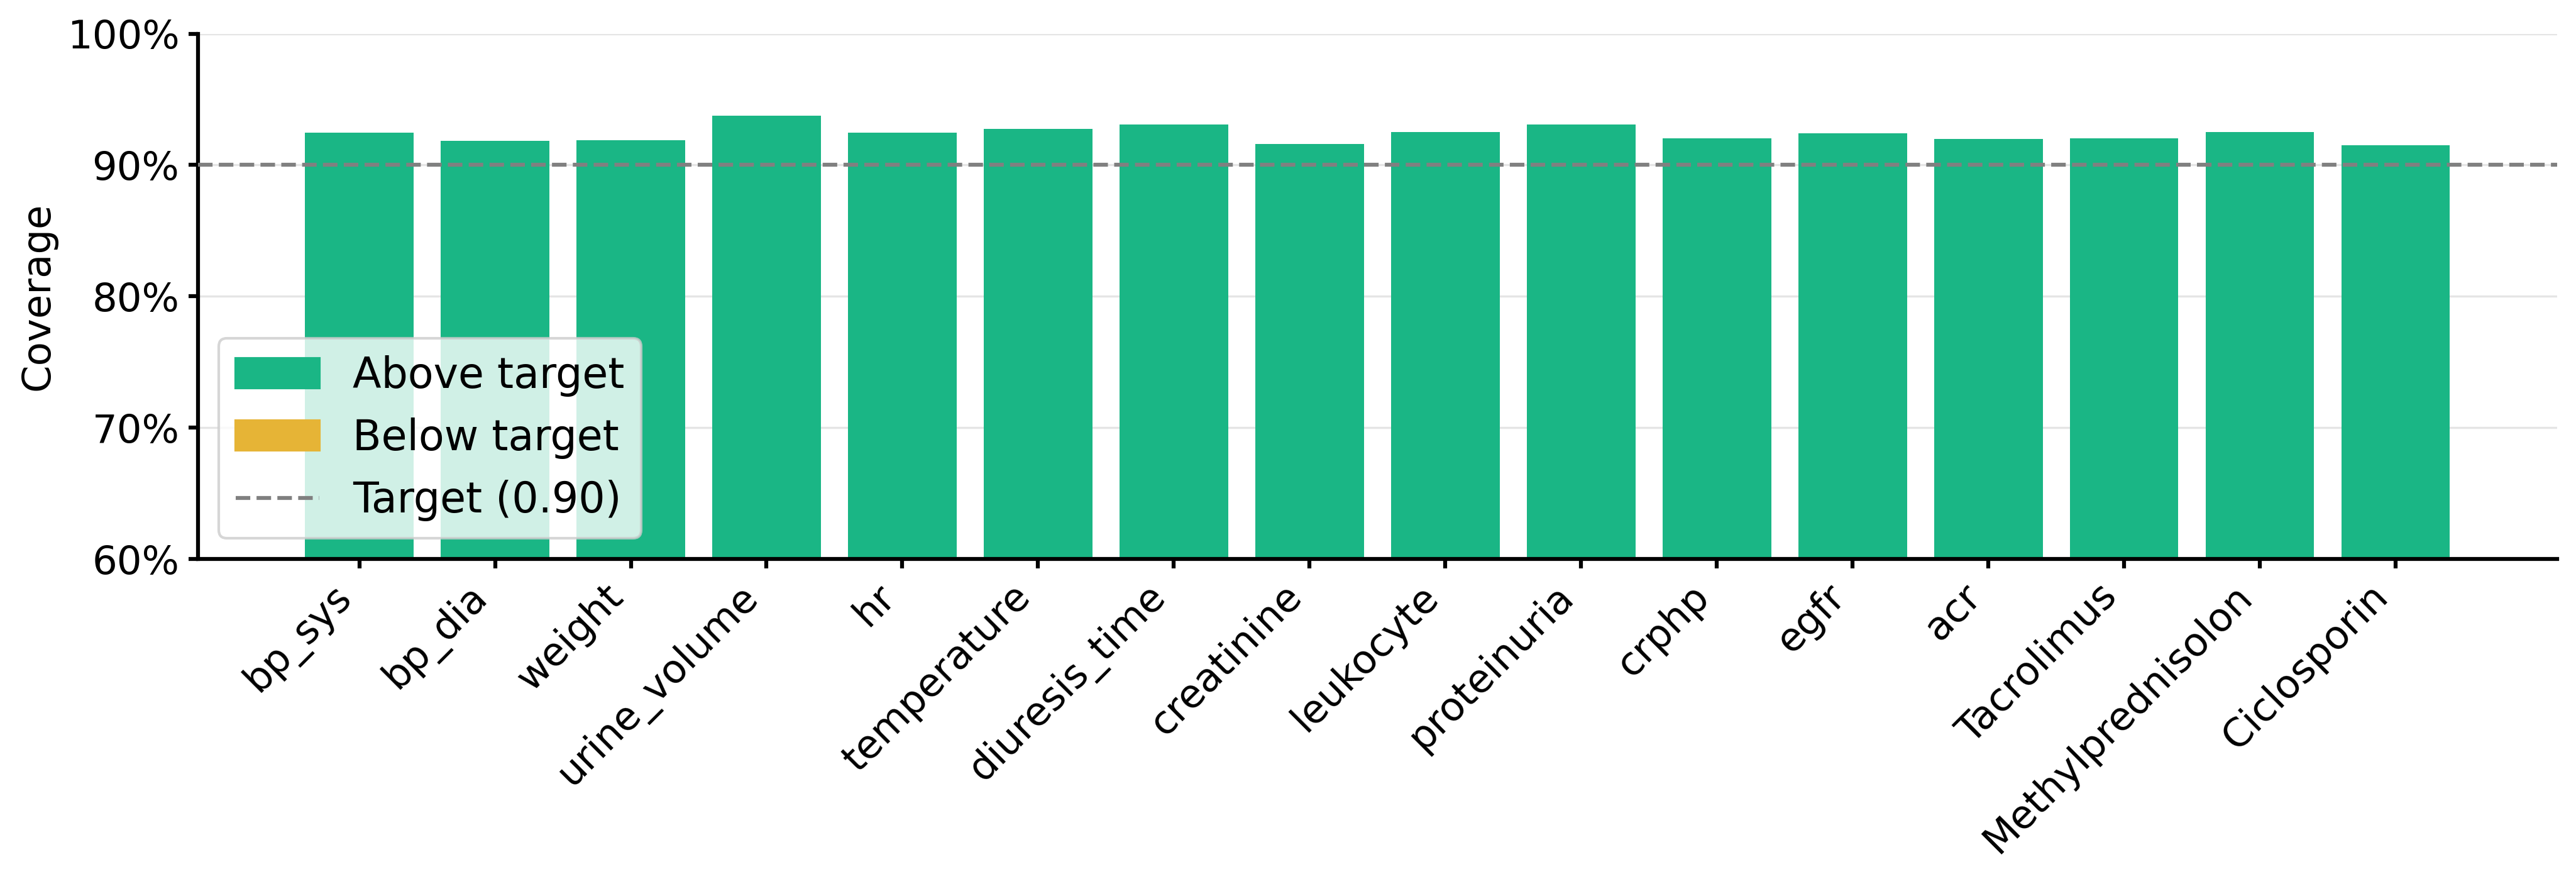

In [127]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#1AB685' if v >= 0.9 else '#E6B436' for v in res[0]]

bars = ax.bar(CONFIG['ts_features'], res[0], color=colors, zorder=2)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=1.5, label='Target (0.90)', zorder=3)

ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Coverage')
ax.set_xticklabels(CONFIG['ts_features'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.grid(axis='y', color='gray', alpha=0.2, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

legend_elements = [
    plt.Rectangle((0,0), 1, 1, color="#1AB685", label='Above target'),
    plt.Rectangle((0,0), 1, 1, color="#E6B436", label='Below target'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Target (0.90)')
]
ax.legend(handles=legend_elements, frameon=True, loc=0)

plt.tight_layout()
plt.savefig(f"../plots/aci.png", dpi=300, bbox_inches="tight")
plt.show()


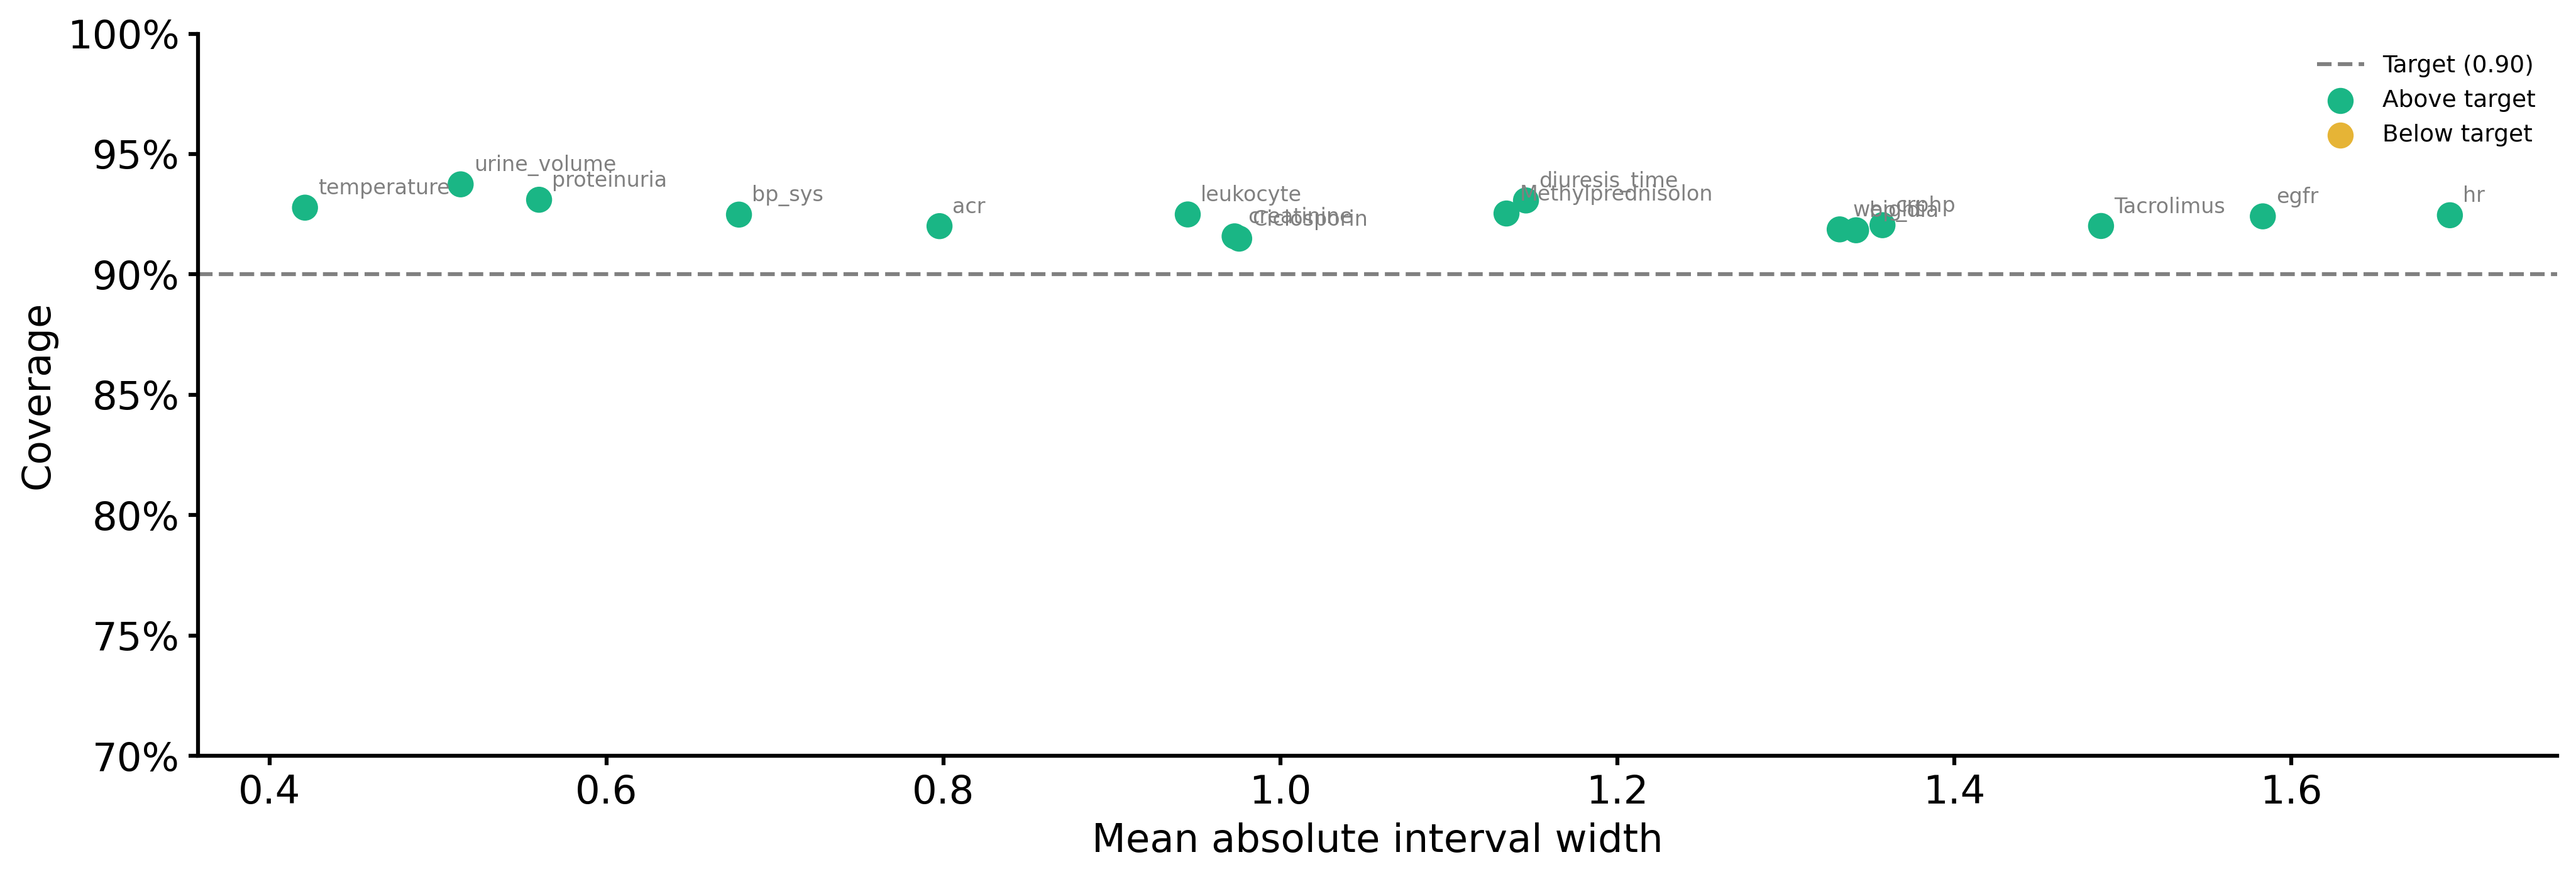

In [135]:
mean_coverage = res[0]
mean_widths = res[1]
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=1.5, zorder=1)

colors = ['#1AB685' if v >= 0.9 else '#E6B436' for v in mean_coverage]
ax.scatter(mean_widths, mean_coverage, color=colors, s=80, zorder=2)

for i, name in enumerate(CONFIG['ts_features']):
    ax.annotate(name, (mean_widths[i], mean_coverage[i]),
                fontsize=8, color='gray',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Mean absolute interval width')
ax.set_ylabel('Coverage')
ax.set_ylim(0.7, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.spines[['top', 'right']].set_visible(False)

legend_elements = [
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Target (0.90)'),
    plt.scatter([], [], color='#1AB685', s=80, label='Above target'),
    plt.scatter([], [], color='#E6B436', s=80, label='Below target'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc=0)

plt.tight_layout()
plt.show()

In [189]:
print(res)

(array([0.92483177, 0.91833251, 0.91869358, 0.93740358, 0.92456918,
       0.92772033, 0.93070737, 0.91580502, 0.92489742, 0.93100279,
       0.92043328, 0.92410963, 0.92003939, 0.92010504, 0.92529132,
       0.91485311]), array([0.67858946, 1.34167284, 1.33192579, 0.51338995, 1.69412947,
       0.42099808, 1.14573033, 0.97278069, 0.94496669, 0.55993817,
       1.3573332 , 1.58309515, 0.79762425, 1.48706129, 1.13416308,
       0.97550118]))


In [128]:
def RCPS(Y_cal_patients, X_cal_patients, Y_test_patients, X_test_patients,
         alpha=0.1, delta=0.05, n_lambdas=100):
    """
    X here is model predictions, Y is ground truth.
    We treat the prediction error directly as the base for intervals,
    no quantile regression refitting needed.
    """

    # --- Step 1: compute base residuals per calibration patient ---
    # base interval = prediction ± base_width
    # where base_width = mean absolute error on that patient
    cal_preds  = []
    cal_truths = []

    for Y, X in zip(Y_cal_patients, X_cal_patients):
        cal_preds.append(np.asarray(X))   # model predictions
        cal_truths.append(np.asarray(Y))  # ground truth

    n = len(cal_preds)

    # --- Step 2: exact UCB search over lambda ---
    # lambda now directly scales the residual width
    # base_width per timestep = |pred - truth| on calibration patients
    # at test time we use the mean calibration residual as base_width

    # compute per-patient mean absolute error as base width
    cal_base_widths = [np.abs(Y - X).mean() for Y, X in zip(cal_truths, cal_preds)]
    global_base_width = np.mean(cal_base_widths)

    lambdas = np.linspace(0.1, 5.0, n_lambdas)

    def compute_losses(lam):
        patient_losses = []
        for pred, truth in zip(cal_preds, cal_truths):
            lower = pred - lam * global_base_width
            upper = pred + lam * global_base_width
            violations = (truth < lower) | (truth > upper)
            patient_losses.append(np.mean(violations))
        return np.array(patient_losses)

    def hoeffding_ucb(lam):
        losses = compute_losses(lam)
        risk_hat = losses.mean()
        ucb = risk_hat + np.sqrt(np.log(n_lambdas / delta) / (2 * n))
        return ucb
    print(f"n calibration patients: {n}")
    print(f"Hoeffding penalty: {np.sqrt(np.log(n_lambdas / delta) / (2 * n)):.4f}")
    print(f"CLT penalty (approx): {1.645 / np.sqrt(n):.4f}")
    print()
    print("Lambda search diagnostics:")

    def clt_ucb(lam):
        losses = compute_losses(lam)
        risk_hat = losses.mean()
        std_err = losses.std() / np.sqrt(n)
        ucb = risk_hat + 1.645 * std_err  # one-sided 95% CI
        return ucb

    for lam in np.linspace(0.1, 5.0, 10):
        losses = compute_losses(lam)
        risk_hat = losses.mean()
        ucb = risk_hat + np.sqrt(np.log(n_lambdas / delta) / (2 * n))
        print(f"  lam={lam:.2f} | risk_hat={risk_hat:.4f} | ucb={ucb:.4f} | satisfied={ucb <= alpha}")  

    # find smallest lambda where UCB <= alpha
    lambda_hat = lambdas[-1]  # default most conservative
    for lam in lambdas:
        if clt_ucb(lam) <= alpha:
            lambda_hat = lam
            break
    # check loss distribution at large lambda
    losses_at_5 = compute_losses(5.0)
    print(f"Mean loss at λ=5.0: {losses_at_5.mean():.4f}")
    print(f"Std  loss at λ=5.0: {losses_at_5.std():.4f}")
    print(f"Max  loss at λ=5.0: {losses_at_5.max():.4f}")
    print(f"% patients with zero loss: {(losses_at_5 == 0).mean():.2%}")
    print(f"% patients with loss > 0.5: {(losses_at_5 > 0.5).mean():.2%}")
    # --- Step 3: apply lambda_hat to test patients ---
    lower_test = []
    upper_test = []
    all_test_violations = []

    for Y, X in zip(Y_test_patients, X_test_patients):
        pred  = np.asarray(X)
        truth = np.asarray(Y)

        lower = pred - lambda_hat * global_base_width
        upper = pred + lambda_hat * global_base_width

        lower_test.append(lower)
        upper_test.append(upper)

        violations = (truth < lower) | (truth > upper)
        all_test_violations.append(np.mean(violations))

    coverage = 1 - np.mean(all_test_violations)

    return lambda_hat, coverage, lower_test, upper_test

In [129]:
test_dataset_rcps, calibration_dataset = random_split(test_dataset, [0.5, 0.5])
test_dataloader_rcps = DataLoader(test_dataset_rcps, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
calibration_dataloader = DataLoader(calibration_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_patients_x = []
test_patients_y = []
calibration_patients_x = []
calibration_patients_y = []

for batch in test_dataloader:
        B = batch['static_categorical_features'].size(0)
        for i in range(B):
            sc = batch['static_categorical_features'][i:i+1]
            sn = batch['static_numerical_features'][i:i+1]
            tf = batch['ts_features'][i:i+1]
            t = batch['timesteps'][i:i+1]
            m = batch['mask'][i:i+1]
            nt = batch['notes_embeddings'][i:i+1]
            nt_timesteps = batch['notes_timesteps'][i:i+1]
            nt_mask = batch['notes_mask'][i:i+1]
            pred_ts, lstm_out, attn, static_encoding = pipeline_predict(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask)

            tf_transposed = tf[0].T.to(device='cpu').detach().numpy()
            pred_ts_transposed = pred_ts[0].T.to(device='cpu').detach().numpy()
            test_patients_x.append(pred_ts_transposed)
            test_patients_y.append(tf_transposed)

for batch in calibration_dataloader:
        B = batch['static_categorical_features'].size(0)
        for i in range(B):
            sc = batch['static_categorical_features'][i:i+1]
            sn = batch['static_numerical_features'][i:i+1]
            tf = batch['ts_features'][i:i+1]
            t = batch['timesteps'][i:i+1]
            m = batch['mask'][i:i+1]
            nt = batch['notes_embeddings'][i:i+1]
            nt_timesteps = batch['notes_timesteps'][i:i+1]
            nt_mask = batch['notes_mask'][i:i+1]
            pred_ts, lstm_out, attn, static_encoding = pipeline_predict(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask)

            tf_transposed = tf[0].T.to(device='cpu').detach().numpy()
            pred_ts_transposed = pred_ts[0].T.to(device='cpu').detach().numpy()
            calibration_patients_x.append(pred_ts_transposed)
            calibration_patients_y.append(tf_transposed)

results = []
for v in range(16):
    lam, cov, lower, upper = RCPS(
        Y_cal_patients=[p[:, v] for p in calibration_patients_y],
        X_cal_patients=[p[:, v] for p in calibration_patients_x],
        Y_test_patients=[p[:, v] for p in test_patients_y],
        X_test_patients=[p[:, v] for p in test_patients_x],
    )
    results.append((lam, cov, lower, upper))
#print(results)

n calibration patients: 338
Hoeffding penalty: 0.1060
CLT penalty (approx): 0.0895

Lambda search diagnostics:
  lam=0.10 | risk_hat=0.9207 | ucb=1.0267 | satisfied=False
  lam=0.64 | risk_hat=0.4871 | ucb=0.5931 | satisfied=False
  lam=1.19 | risk_hat=0.2901 | ucb=0.3962 | satisfied=False
  lam=1.73 | risk_hat=0.1842 | ucb=0.2902 | satisfied=False
  lam=2.28 | risk_hat=0.1237 | ucb=0.2297 | satisfied=False
  lam=2.82 | risk_hat=0.0775 | ucb=0.1835 | satisfied=False
  lam=3.37 | risk_hat=0.0237 | ucb=0.1297 | satisfied=False
  lam=3.91 | risk_hat=0.0142 | ucb=0.1203 | satisfied=False
  lam=4.46 | risk_hat=0.0120 | ucb=0.1181 | satisfied=False
  lam=5.00 | risk_hat=0.0078 | ucb=0.1138 | satisfied=False
Mean loss at λ=5.0: 0.0078
Std  loss at λ=5.0: 0.0212
Max  loss at λ=5.0: 0.1250
% patients with zero loss: 87.87%
% patients with loss > 0.5: 0.00%
n calibration patients: 338
Hoeffding penalty: 0.1060
CLT penalty (approx): 0.0895

Lambda search diagnostics:
  lam=0.10 | risk_hat=0.9236 

Feature  0 | lambda: 2.674 | coverage: 0.907
Feature  1 | lambda: 2.377 | coverage: 0.908
Feature  2 | lambda: 2.228 | coverage: 0.910
Feature  3 | lambda: 2.129 | coverage: 0.914
Feature  4 | lambda: 2.080 | coverage: 0.913
Feature  5 | lambda: 2.030 | coverage: 0.912
Feature  6 | lambda: 1.981 | coverage: 0.911
Feature  7 | lambda: 1.931 | coverage: 0.907
Feature  8 | lambda: 1.931 | coverage: 0.908
Feature  9 | lambda: 1.931 | coverage: 0.907
Feature 10 | lambda: 1.931 | coverage: 0.908
Feature 11 | lambda: 1.931 | coverage: 0.907
Feature 12 | lambda: 1.931 | coverage: 0.910
Feature 13 | lambda: 1.931 | coverage: 0.908
Feature 14 | lambda: 1.931 | coverage: 0.909
Feature 15 | lambda: 1.931 | coverage: 0.909


/var/folders/5f/0c4wpv9138q54mz39x6gcjrw0000gn/T/ipykernel_50864/2256009375.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right')


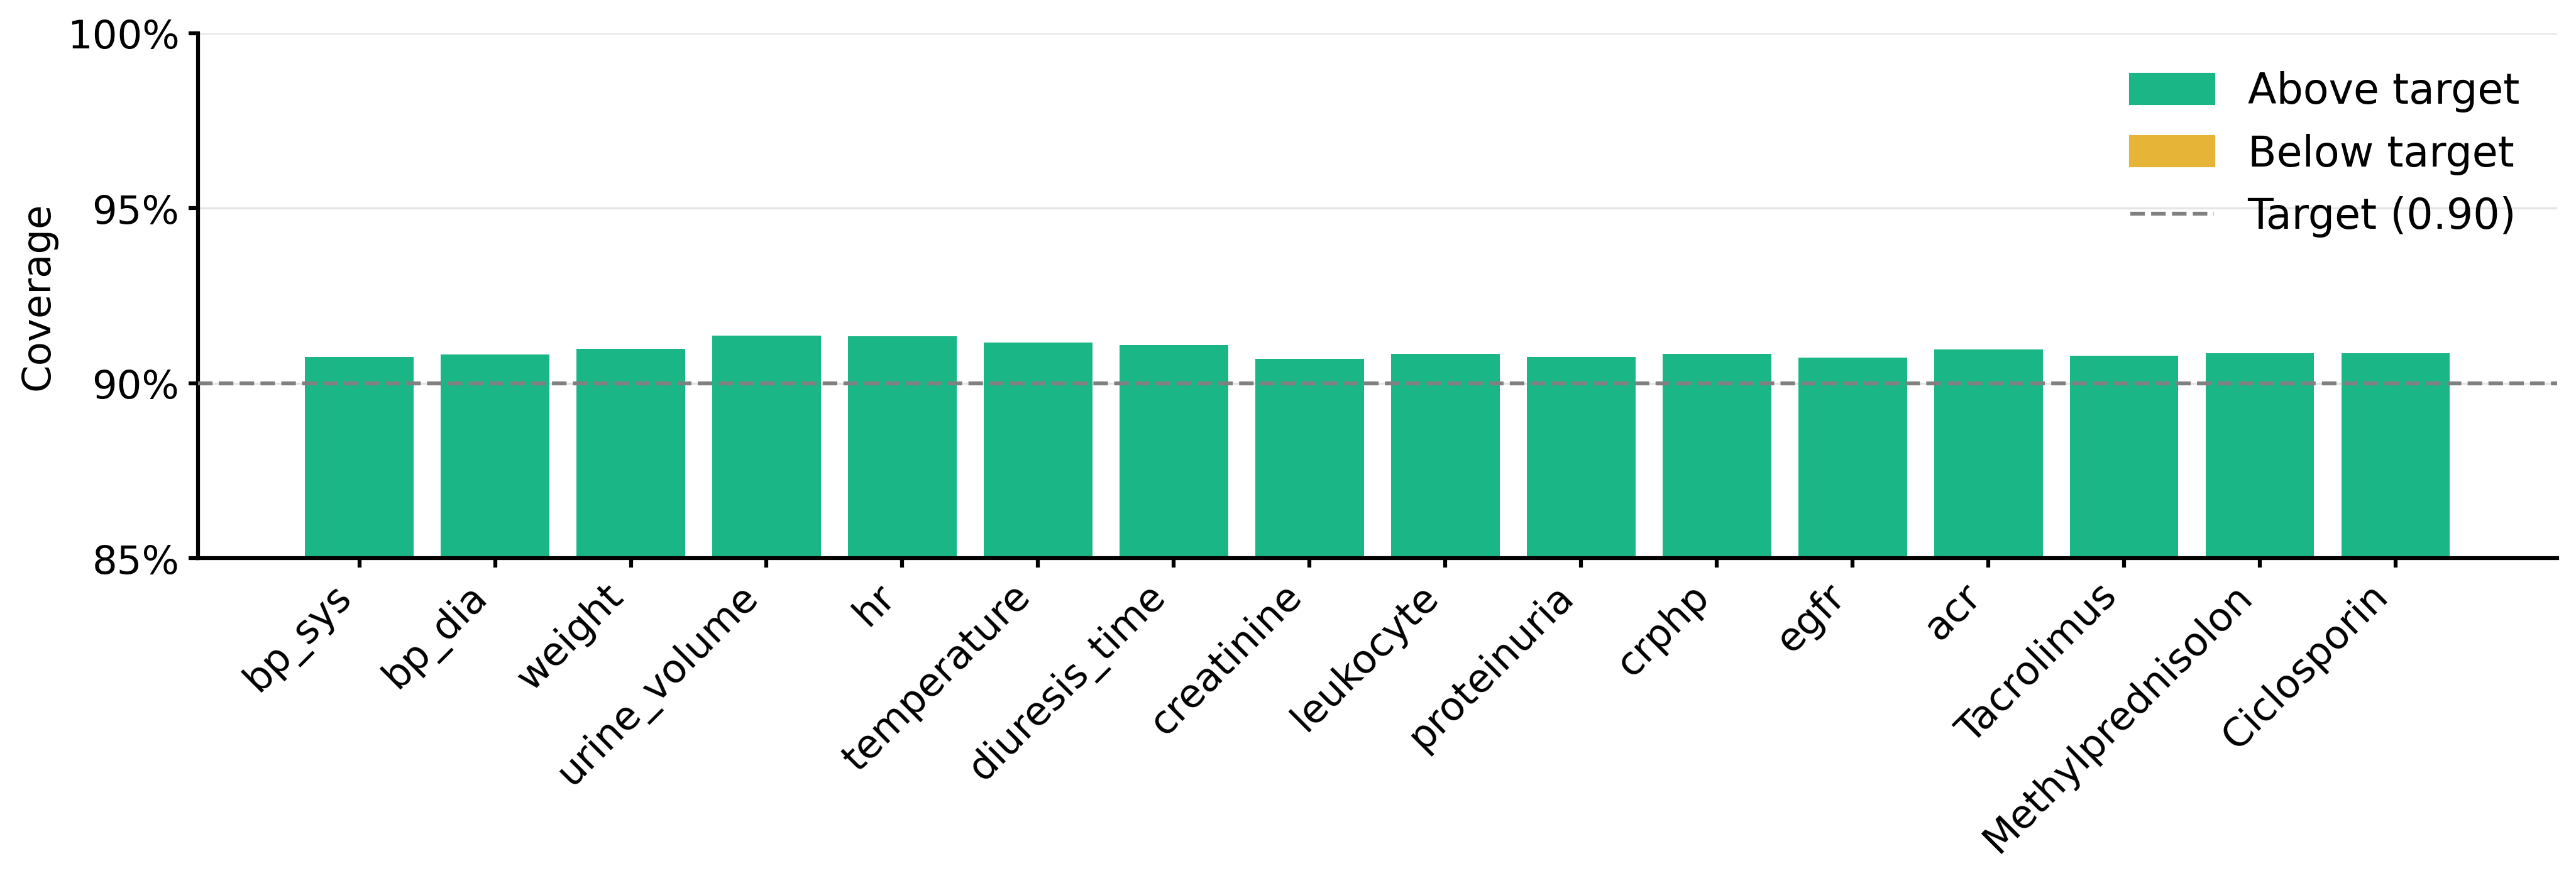

In [141]:
for i, (lam, cov, lower, upper) in enumerate(results):
    print(f"Feature {i:2d} | lambda: {lam:.3f} | coverage: {cov:.3f}")

rcps_coverage = np.array([r[1] for r in results])
names = CONFIG['ts_features']

fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#1AB685' if v >= 0.9 else '#E6B436' for v in rcps_coverage]
ax.bar(names, rcps_coverage, color=colors, zorder=2)

ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=1.5, label='Target (0.90)', zorder=3)

ax.set_ylim(0.85, 1.0)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('Coverage')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.grid(axis='y', color='gray', alpha=0.2, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

legend_elements = [
    plt.Rectangle((0,0), 1, 1, color='#1AB685', label='Above target'),
    plt.Rectangle((0,0), 1, 1, color='#E6B436', label='Below target'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Target (0.90)')
]
ax.legend(handles=legend_elements, frameon=False)

plt.tight_layout()
plt.savefig(f"../plots/rcps.png", dpi=300, bbox_inches="tight")
plt.show()

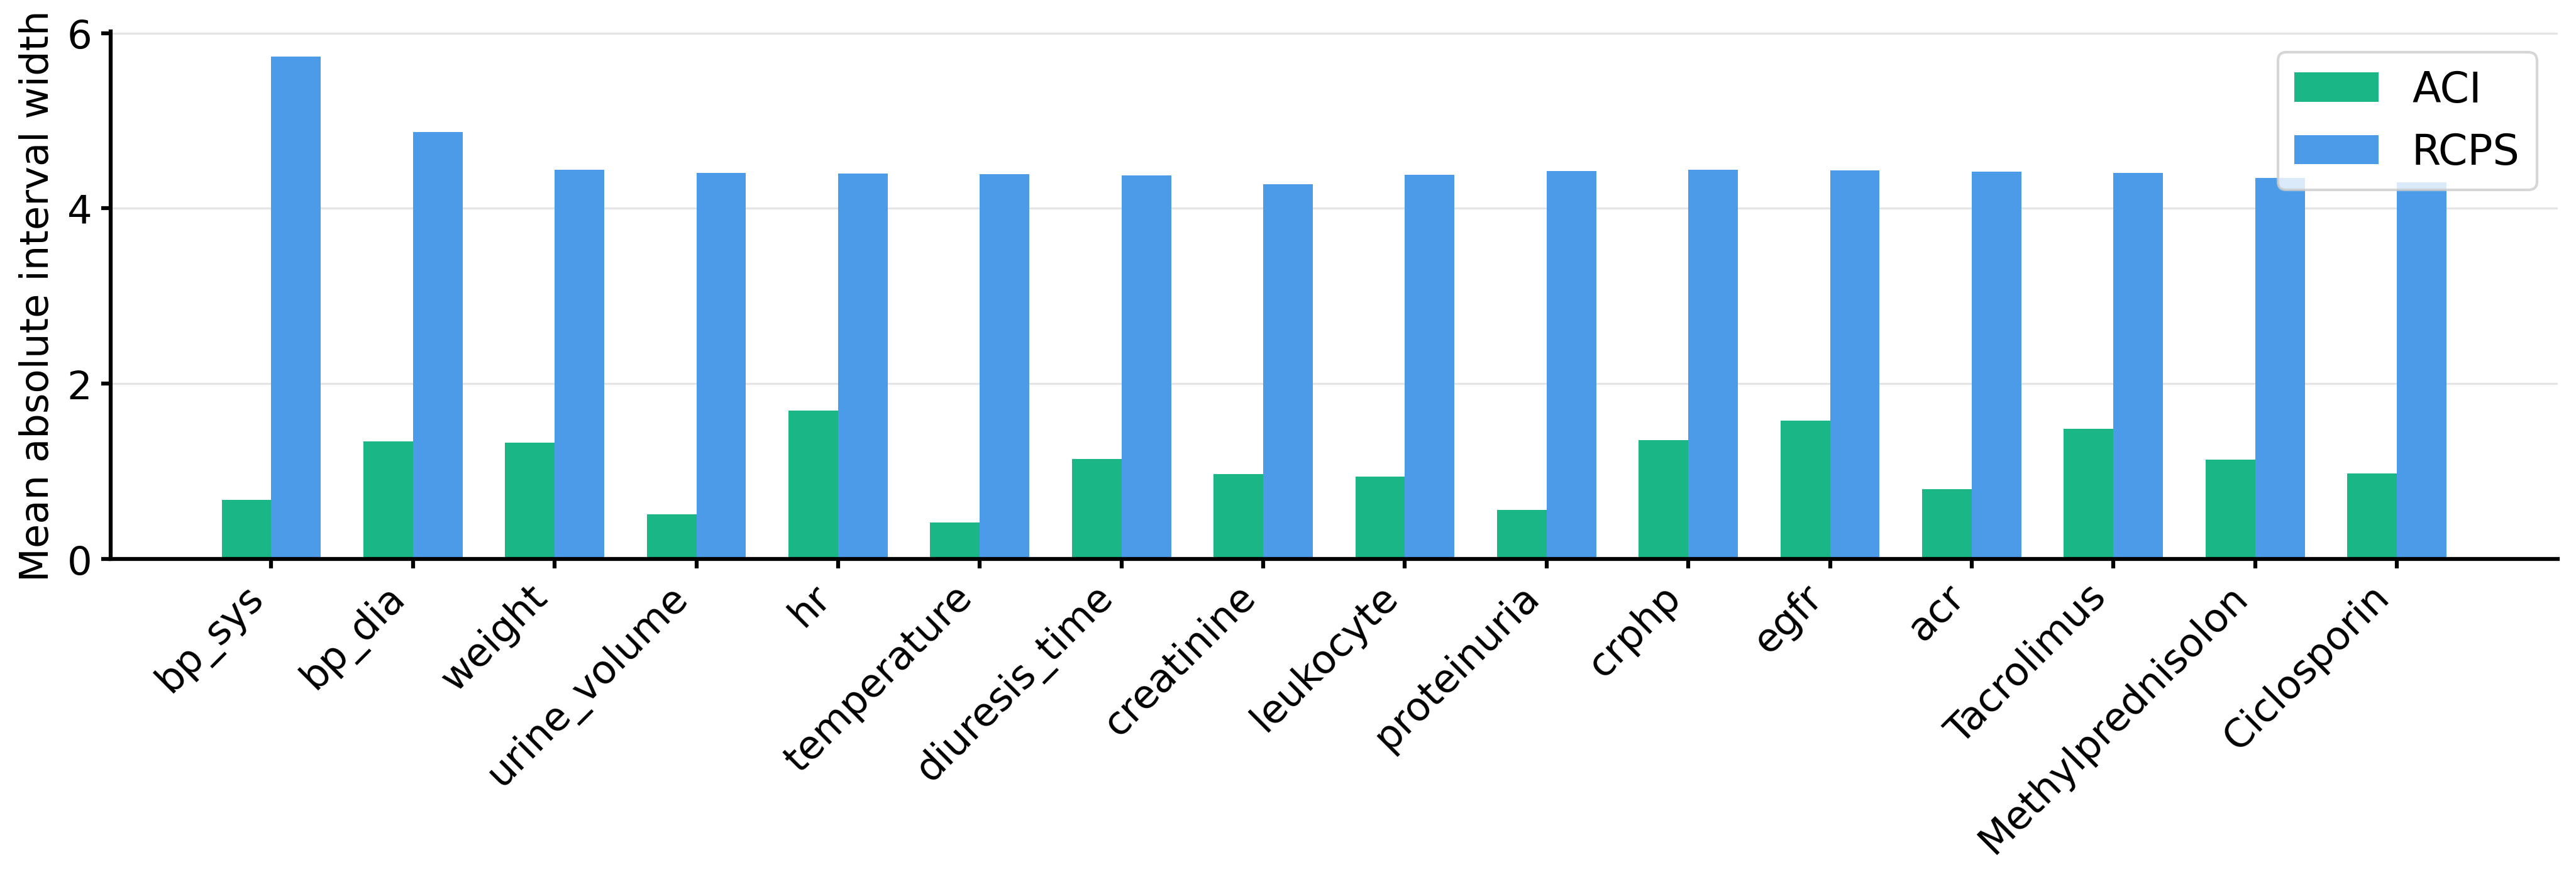

In [139]:
rcps_widths = np.array([
    np.mean([np.mean(u - l) for l, u in zip(results[v][2], results[v][3])])
    for v in range(16)
])

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
aci_widths = mean_widths
ax.bar(x - width/2, aci_widths,  width, color='#1AB685', label='ACI',  zorder=2)
ax.bar(x + width/2, rcps_widths, width, color='#4C9BE8', label='RCPS', zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('Mean absolute interval width')
ax.grid(axis='y', color='gray', alpha=0.2, zorder=1)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

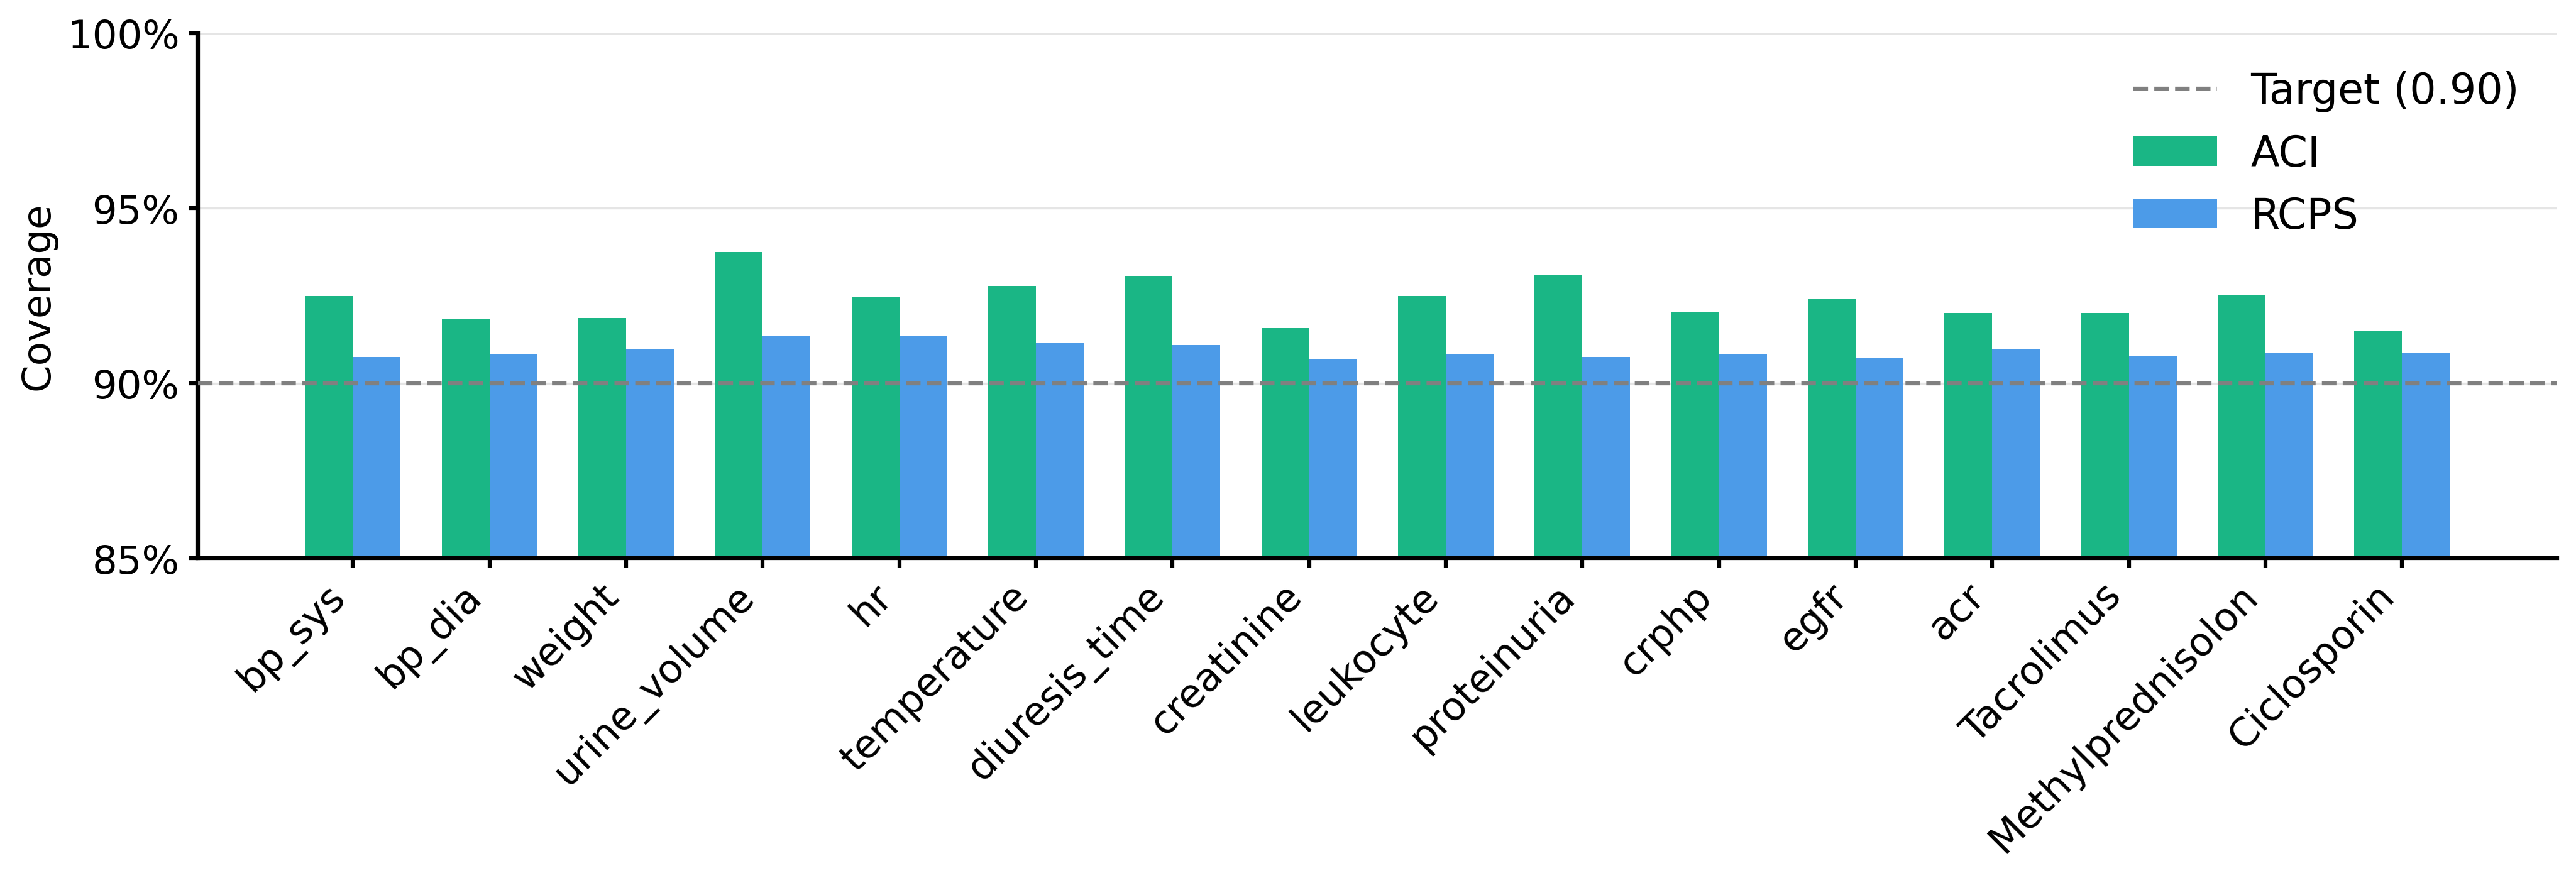

In [142]:
aci_coverage = mean_coverage   # your ACI coverage array
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))

bars_aci  = ax.bar(x - width/2, aci_coverage,  width, color='#1AB685', label='ACI',  zorder=2)
bars_rcps = ax.bar(x + width/2, rcps_coverage, width, color='#4C9BE8', label='RCPS', zorder=2)

ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=1.5, label='Target (0.90)', zorder=3)

ax.set_ylim(0.85, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('Coverage')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.grid(axis='y', color='gray', alpha=0.2, zorder=1)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()